# Phase 2 Final Mass Analysis

This notebook analyzes the effects of treatments on the final tissue mass, shell mass, and T:S ratio of experimental oysters. Growth analysis is in a separate notebook. 

### load packages, read in data, etc.

In [2]:
library(lme4) #for linear mixed effects model
library(readr) #to read in data
library(emmeans) #for post hocs
library(esquisse) #interface for building plots
library(dplyr) #for data wrangling
library(nlme) #for linear mixed effects model
library(car) #for the Levene test
library(ggplot2) #for graphs
library(plotrix) #for standard error
library(performance) #model testing
library(lmtest) #another option than levene test for variance

In [3]:
getwd()
setwd("/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC")

[1] "/Users/sophiemontague/Desktop/MontagueORCC_repo/MontagueORCC"

In [4]:
options(contrasts = c("contr.sum","contr.poly")) #could also be contr.treatment for unequal groups sum
getOption("contrasts") 

[1] "contr.sum"  "contr.poly"

In [5]:
Growth_Data_forR <- read_csv("Oyster_Weight_Data/growth_phase2.1_weightsSKM.csv", 
                             col_types = cols(Phase_1_temp = col_factor(), 
                                              Phase_1_DO =col_factor(), 
                                              Phase_2.1_temp =col_factor(), 
                                              Phase_2.1_DO=col_factor(), 
                                              Phase_1_rep =col_factor(), 
                                              Phase_2_rep =col_factor(),
                                              Ratio_tissue_shell_mg = col_double(),
                                              Phase1_Phase2_rep = col_factor(),
                                              Phase_1_treat = col_factor(),
                                              Phase_2_treat = col_factor(),
                                              Phase_2_rep_R = col_factor(),
                                              Phase_1_rep_R = col_factor()))

### Filter to exclude dead oysters

In [6]:
Growth_Data_forR_full <- Growth_Data_forR %>%
  filter(Exclude_all != "Y" | is.na(Exclude_all)) %>%
  mutate(prop_tissue_growth = Actual_tissue_growth_mg / Actual_tissue_pre_mg,
    prop_shell_growth = Actual_shell_growth_mg / Actual_shell_pre_mg, 
    tissuegrowthratio = Actual_tissue_post_mg/Actual_tissue_pre_mg,
    shellgrowthratio = Actual_shell_post_mg/Actual_shell_pre_mg,
    log_shell_growth_mg = log(Actual_shell_growth_mg),
    whole_growth_mg = Dry_weight_post - Dry_weight_pre,
    meat_yield_post = Actual_tissue_post_mg/Dry_weight_post,
    shell_yield_post = Actual_shell_post_mg/Dry_weight_post)

# 1. Effect of phase 2, TISSUE

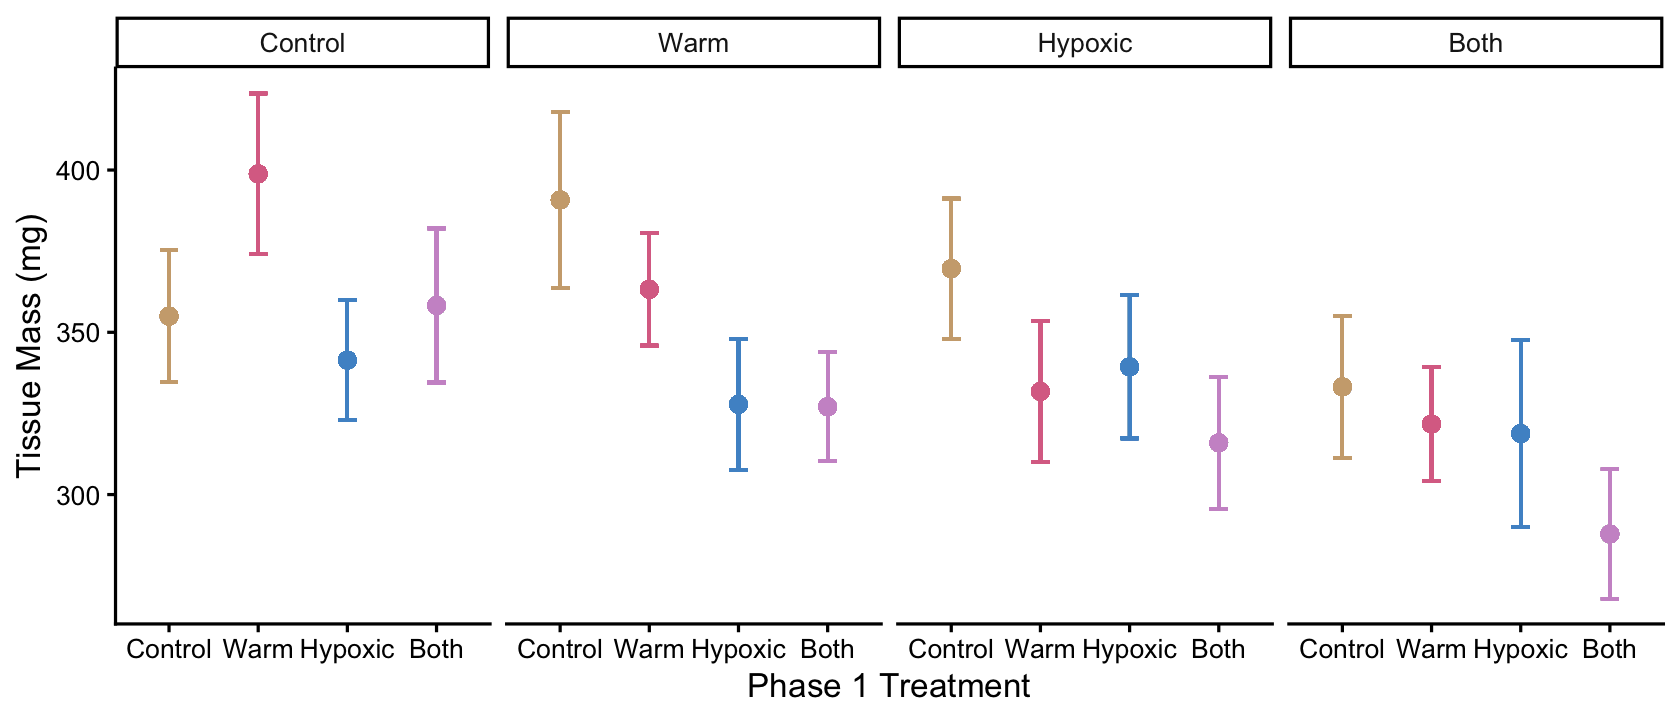

In [7]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, TISSUE
summary_stats_t <- Growth_Data_forR_full %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_post = mean(Actual_tissue_post_mg, na.rm = TRUE),
    se_post = std.error(Actual_tissue_post_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_t$Phase_1_treat <- factor(summary_stats_t$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_t$Phase_2_treat <- factor(summary_stats_t$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_t, aes(x = Phase_1_treat, y = mean_post, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_post - se_post, ymax = mean_post + se_post), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs( x = "Phase 1 Treatment", y = "Tissue Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

## statistical analysis

In [8]:
#log transformed
m1_post <- lmer(log(Actual_tissue_post_mg)~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
             (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
             (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Growth_Data_forR_full, REML=TRUE)

aov_tab <- Anova(m1_post, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1.488928e+04,1,23.74589,0.0000
Phase_1_DO,6.288544e+00,1,16.54189,0.0229
Phase_1_temp,1.018014e-01,1,16.54068,0.7537
Phase_2.1_temp,3.448836e-01,1,20.00036,0.5636
Phase_2.1_DO,1.479479e+00,1,20.00080,0.2380
Phase_1_DO:Phase_1_temp,1.629089e-02,1,16.54502,0.9000
Phase_1_DO:Phase_2.1_temp,6.091865e-01,1,19.99671,0.4442
Phase_1_temp:Phase_2.1_temp,7.550090e-02,1,19.98271,0.7863
Phase_1_DO:Phase_2.1_DO,9.734659e-05,1,20.00162,0.9922


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,0.6144303,0.8650683
,1101,NA,NA


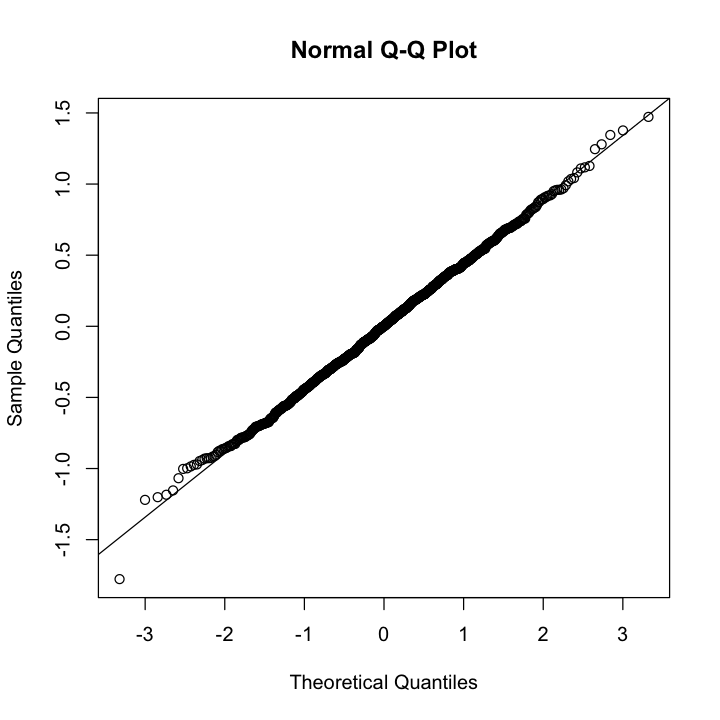

In [10]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

leveneTest(log(Actual_tissue_post_mg)~Phase_1_treat*Phase_2_treat, Growth_Data_forR_full) 
m1.e <- residuals(m1_post) 
qqnorm(m1.e)
qqline(m1.e)

passes diagnostics

In [11]:
#posthocs
emmeans(m1_post,specs = pairwise ~ Phase_1_DO, adjust = "none")
emmeans(m1_post,specs = pairwise ~ Phase_1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean     SE   df lower.CL upper.CL
 Hyp          5.66 0.0510 29.5     5.56     5.77
 Norm         5.76 0.0509 29.4     5.66     5.87

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast   estimate     SE   df t.ratio p.value
 Hyp - Norm   -0.101 0.0402 16.5  -2.508  0.0229

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 


NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_DO emmean     SE   df lower.CL upper.CL
 Warm         Hyp            5.63 0.0690 27.8     5.48     5.77
 Ambient      Hyp            5.69 0.0689 27.6     5.55     5.83
 Warm         Norm           5.79 0.0690 27.8     5.64     5.93
 Ambient      Norm           5.75 0.0687 27.4     5.61     5.89

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast                   estimate     SE   df t.ratio p.value
 Warm Hyp - Ambient Hyp      -0.0642 0.0486 23.3  -1.321  0.1994
 Warm Hyp - Warm Norm        -0.1593 0.0930 23.8  -1.714  0.0995
 Warm Hyp - Ambient Norm     -0.1208 0.0974 27.6  -1.240  0.2254
 Ambient Hyp - Warm Norm     -0.0951 0.0975 27.7  -0.976  0.3377
 Ambient Hyp - Ambient Norm  -0.0566 0.0926 23.5  -0.611  0.5469
 Warm Norm - Ambient Norm     0.0385 0.0484 23.0   0.795  0.4345

Result

### plotting significant interactions

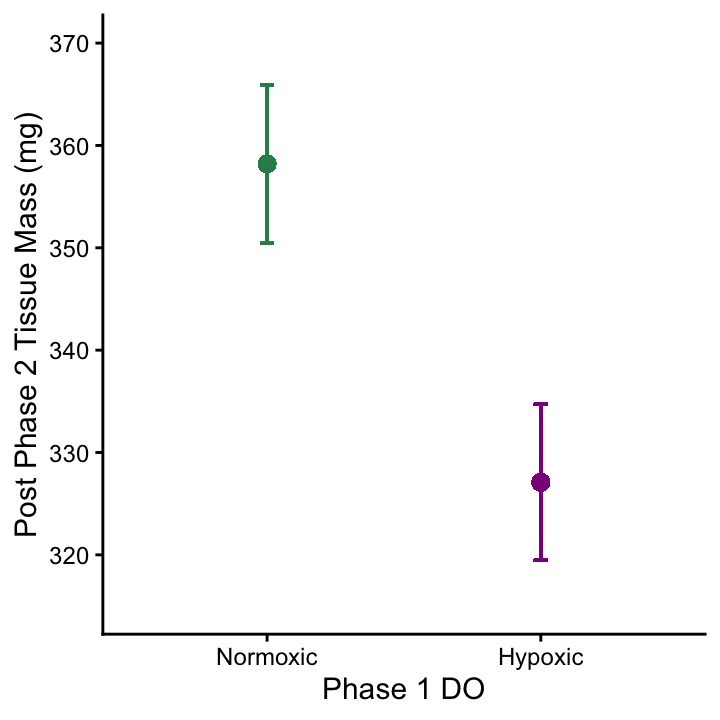

In [13]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

stats_t <- Growth_Data_forR_full %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_post = mean(Actual_tissue_post_mg, na.rm = TRUE),
    se_post = std.error(Actual_tissue_post_mg, na.rm = TRUE))
#reorder
stats_t$Phase_1_DO <- factor(stats_t$Phase_1_DO, 
                               levels = c("Norm","Hyp"))
#Tissue plot with mean and SD
ggplot(stats_t, aes(x = Phase_1_DO, y = mean_post, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_post - se_post, ymax = mean_post + se_post), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  labs(x = "Phase 1 DO", y = "Post Phase 2 Tissue Mass (mg)") +
ylim(315, 370)+
  theme(legend.position = "none") # Remove legend

### Regardless of phase 2 treatment, oysters were smaller when they experienced early life hypoxia (p = 0.023)

<details>
<summary> Show R code for shell mass and Phase_1_temp:Phase_2_DO graph </summary>

```r

#format display for jupyter
options(repr.plot.width = 8, repr.plot.height = 6)

#shell growth and Phase_1_temp:Phase_2.1_DO
stats_s <- Growth_Data_forR_full %>%
  group_by(Phase_1_temp, Phase_2.1_DO) %>%
  mutate(
    mean_post = mean(Actual_shell_post_mg, na.rm = TRUE),
    se_post = std.error(Actual_shell_post_mg, na.rm = TRUE))

#reorder Phase_1_temp:Phase_2.1_DO
stats_s$Phase_1_temp <- factor(stats_s$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
stats_s$Phase_2.1_DO <- factor(stats_s$Phase_2.1_DO, 
                                        levels = c("Norm","Hyp"))

#plot with mean and SD, SHELL
ggplot(stats_s, aes(x = Phase_1_temp, y = mean_post, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_post - se_post, ymax = mean_post + se_post), 
                width = 0.1, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(vars(Phase_2.1_DO), labeller = as_labeller(c("Norm" = "Normoxic", "Hyp" = "Hypoxic")),
             scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Post Phase 2 Shell Mass (mg)") +
  scale_x_discrete(labels = c("Norm" = "Normoxic", "Hyp" = "Hypoxic")) +
  theme(legend.position = "none") # Remove legend

### When exposed to early life warming, oysters were larger in phase 2 normoxia than hypoxia (p = 0.07)

# Effect of phase 2, SHELL

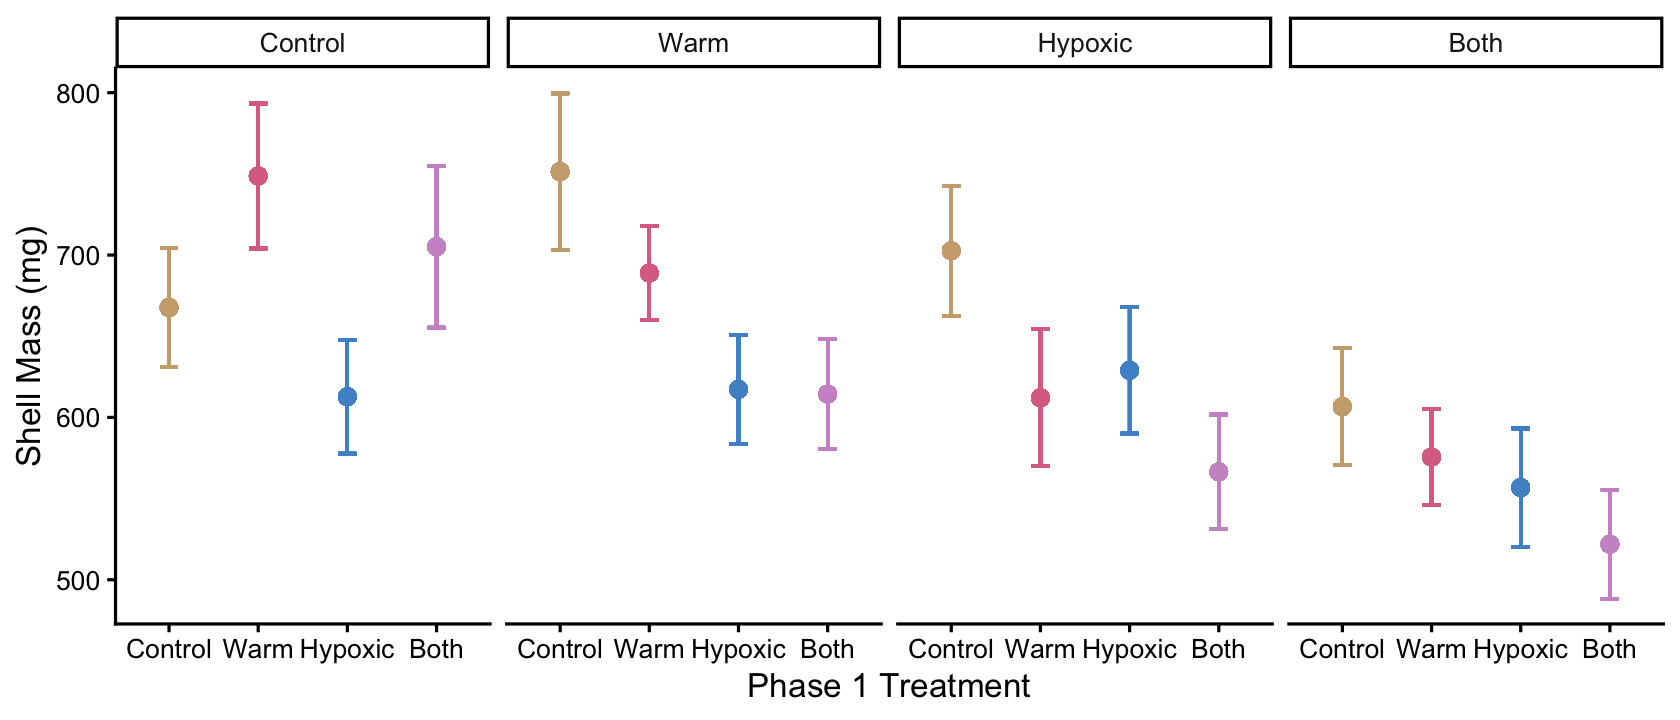

In [54]:
#format for jupyter
options(repr.plot.width = 14, repr.plot.height = 6)

#all, Shell
summary_stats_s <- Growth_Data_forR_full %>%
  group_by(Phase_1_treat, Phase_2_treat) %>%
  mutate(
    mean_post = mean(Actual_shell_post_mg, na.rm = TRUE),
    se_post = std.error(Actual_shell_post_mg, na.rm = TRUE))

  #reorder Phase_1_treat and Phase_2_treat
  summary_stats_s$Phase_1_treat <- factor(summary_stats_s$Phase_1_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  summary_stats_s$Phase_2_treat <- factor(summary_stats_s$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp", "Both"))
  
  #plot with mean and SD, TISSUE
  ggplot(summary_stats_s, aes(x = Phase_1_treat, y = mean_post, color = Phase_1_treat)) +
    geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
    geom_errorbar(aes(ymin = mean_post - se_post, ymax = mean_post + se_post), 
                  width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
    theme_classic(base_size = 20) +
    guides(color = "none") + # Remove legend for color
    facet_wrap(vars(Phase_2_treat), 
               labeller = as_labeller(c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")), 
               scales = "fixed", nrow = 1) + # Facet by Phase_2_treat
    scale_color_manual(values = c("Hyp" = "steelblue3", "Warm" = "palevioletred", "Cont" = "burlywood3", "Both" = "plum3")) +
    labs( x = "Phase 1 Treatment", y = "Shell Mass (mg)") +
    scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
    theme(legend.position = "none") # Remove legend

## statistical analysis

In [14]:
m2_post <- lmer(Actual_shell_post_mg~ Phase_1_DO*Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO+
                  (1|Phase_2_rep_R)+(1|Phase_1_rep_R)+
                  (1|Phase_2_rep_R:Phase_1_DO)+(1|Phase_2_rep_R:Phase_1_temp)+(1|Phase_2_rep_R:Phase_1_DO:Phase_1_temp), data = Growth_Data_forR_full, REML=TRUE)

aov_tab<-Anova(m2_post, test="F", type="III")

#remove scientific notation
aov_tab %>%
  mutate(`Pr(>F)` = round(`Pr(>F)`, 4))

boundary (singular) fit: see help('isSingular')



,F,Df,Df.res,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),340.32383873,1,21.78257,0.0000
Phase_1_DO,6.26758072,1,20.49120,0.0208
Phase_1_temp,0.33612270,1,15.27128,0.5705
Phase_2.1_temp,0.33106157,1,20.00033,0.5715
Phase_2.1_DO,1.41952594,1,20.00057,0.2474
Phase_1_DO:Phase_1_temp,0.27376540,1,15.27418,0.6083
Phase_1_DO:Phase_2.1_temp,0.28662790,1,20.00070,0.5983
Phase_1_temp:Phase_2.1_temp,1.42758968,1,19.98437,0.2461
Phase_1_DO:Phase_2.1_DO,0.21176862,1,20.00305,0.6503


Warning message in leveneTest.default(y = y, group = group, ...):
“group coerced to factor.”


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,15,1.547473,0.08191511
,1101,NA,NA


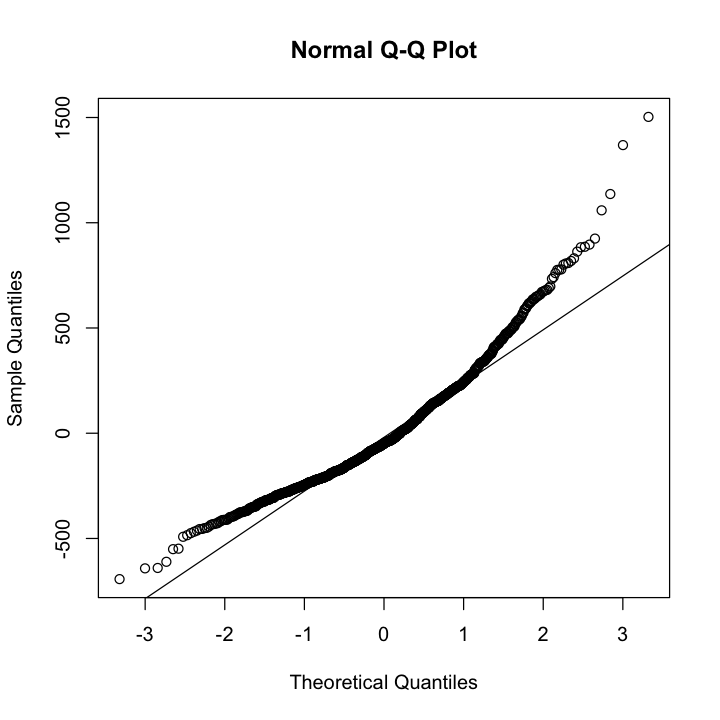

In [63]:
#format for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

#diagnostics
leveneTest(Actual_shell_post_mg~Phase1_Phase2_treat, Growth_Data_forR_full)
m1.e <- residuals(m2_post) 
qqnorm(m1.e)
qqline(m1.e)

In [64]:
#posthocs
emmeans(m2_post,specs = pairwise ~ Phase_1_DO, adjust = "none")
emmeans(m2_post,specs = pairwise ~ Phase_1_temp*Phase_2.1_DO, adjust = "none")
emmeans(m2_post,specs = pairwise ~ Phase_1_temp*Phase_2.1_temp*Phase_2.1_DO, adjust = "none")

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_DO emmean SE   df lower.CL upper.CL
 Hyp           603 37 27.4      527      679
 Norm          670 37 27.4      594      746

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast   estimate   SE   df t.ratio p.value
 Hyp - Norm    -66.6 26.6 20.5  -2.504  0.0208

Results are averaged over the levels of: Phase_1_temp, Phase_2.1_temp, Phase_2.1_DO 
Degrees-of-freedom method: kenward-roger 


NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Warm         Hyp             569 50.3 24.4      465      673
 Ambient      Hyp             624 50.2 24.3      520      727
 Warm         Norm            691 50.3 24.4      588      795
 Ambient      Norm            662 50.1 24.1      559      766

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                   estimate   SE   df t.ratio p.value
 Warm Hyp - Ambient Hyp        -55.0 28.1 21.9  -1.958  0.0631
 Warm Hyp - Warm Norm         -122.2 69.5 22.6  -1.759  0.0922
 Warm Hyp - Ambient Norm       -93.3 71.0 24.3  -1.314  0.2011
 Ambient Hyp - Warm Norm       -67.2 71.0 24.4  -0.946  0.3534
 Ambient Hyp - Ambient Norm    -38.3 69.3 22.4  -0.553  0.5860
 Warm Norm - Ambient Norm       28.9 28.0 21.5   1.034  0.3128

Results are averaged over the levels of: Phase_1_DO, Phase_2.1_temp 
Degrees-of-freedo

NOTE: Results may be misleading due to involvement in interactions



$emmeans
 Phase_1_temp Phase_2.1_temp Phase_2.1_DO emmean   SE   df lower.CL upper.CL
 Warm         Warm           Hyp             549 70.3 23.6      404      695
 Ambient      Warm           Hyp             583 70.2 23.4      438      728
 Warm         Ambient        Hyp             589 70.2 23.5      444      734
 Ambient      Ambient        Hyp             665 70.2 23.4      520      810
 Warm         Warm           Norm            652 70.2 23.5      507      797
 Ambient      Warm           Norm            684 70.1 23.3      539      829
 Warm         Ambient        Norm            730 70.3 23.6      585      875
 Ambient      Ambient        Norm            640 70.1 23.3      495      785

Results are averaged over the levels of: Phase_1_DO 
Degrees-of-freedom method: kenward-roger 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate   SE   df t.ratio p.value
 Warm Warm Hyp - Ambient Warm Hyp             -33.83 36.8 24.3  -0.920  0.3667
 Wa

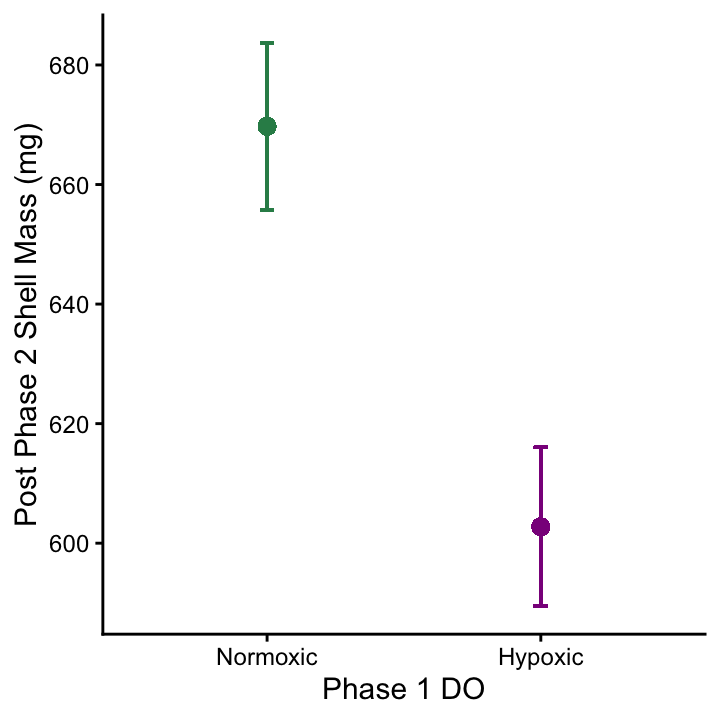

In [17]:
#format display for jupyter
options(repr.plot.width = 6, repr.plot.height = 6)

stats_s <- Growth_Data_forR_full %>%
  group_by(Phase_1_DO) %>%
  mutate(
    mean_post = mean(Actual_shell_post_mg, na.rm = TRUE),
    se_post = std.error(Actual_shell_post_mg, na.rm = TRUE))
#reorder
stats_s$Phase_1_DO <- factor(stats_s$Phase_1_DO, 
                               levels = c("Norm","Hyp"))
#Tissue plot with mean and SD
ggplot(stats_s, aes(x = Phase_1_DO, y = mean_post, color = Phase_1_DO)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_post - se_post, ymax = mean_post + se_post), 
                width = 0.05, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 18) +
  guides(color = "none") + # Remove legend for color
  scale_color_manual(values = c("Hyp" = "darkmagenta", "Norm" = "seagreen")) +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Norm" = "Normoxic")) +
  labs(x = "Phase 1 DO", y = "Post Phase 2 Shell Mass (mg)") +
  theme(legend.position = "none") # Remove legend

### Oysters that experienced early life hypoxia were smaller at the end of the experiment (p = 0.0208)

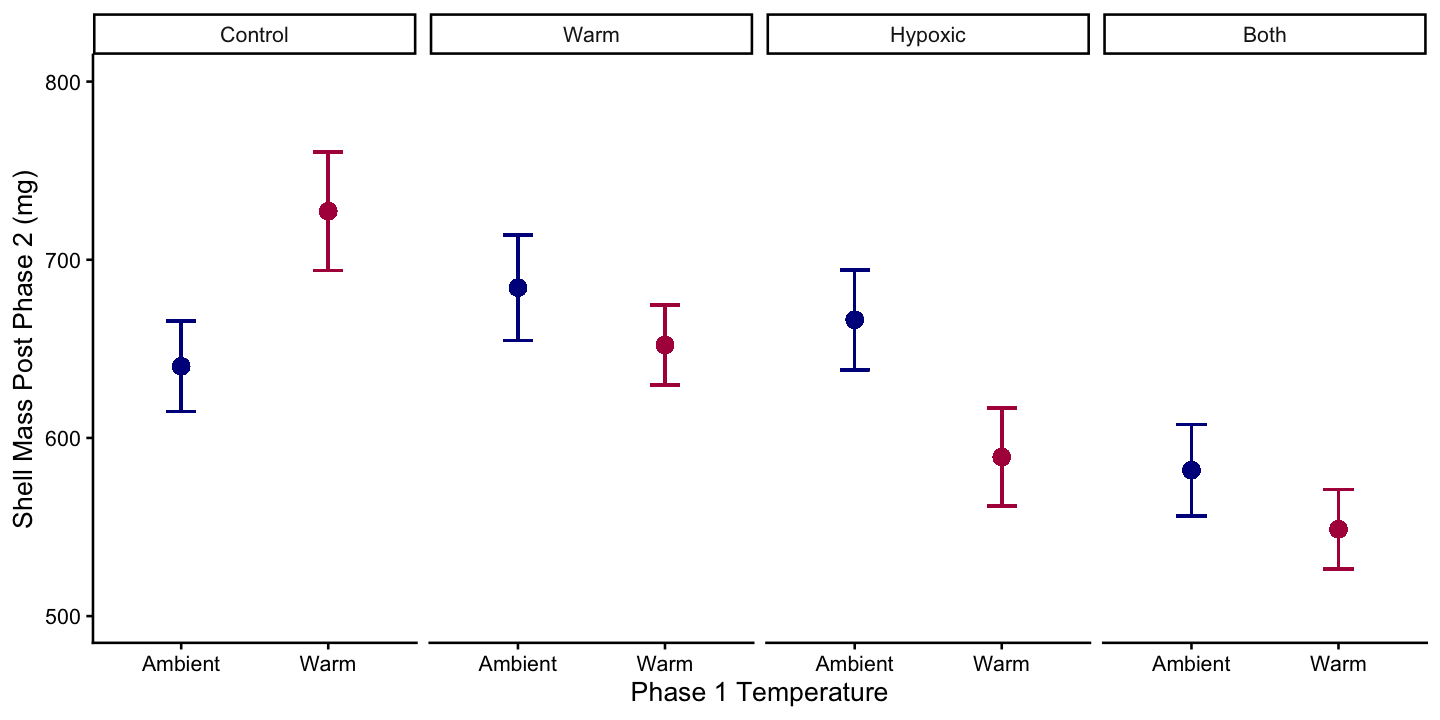

In [15]:
#format for jupyter
options(repr.plot.width = 12, repr.plot.height = 6)

# plot Phase_1_temp:Phase_2.1_temp:Phase_2.1_DO shell post phase 2 
summary_stats_s <- Growth_Data_forR_full%>%
  group_by(Phase_1_temp, Phase_2_treat) %>%
  mutate(
    mean_growth = mean(Actual_shell_post_mg, na.rm = TRUE),
    se_growth = std.error(Actual_shell_post_mg, na.rm = TRUE))

#reorder Phase_1_treat and Phase_2_treat
summary_stats_s$Phase_1_temp <- factor(summary_stats_s$Phase_1_temp, 
                                        levels = c("Ambient", "Warm"))
summary_stats_s$Phase_2_treat <- factor(summary_stats_s$Phase_2_treat, 
                                        levels = c("Cont", "Warm","Hyp",  "Both"))

#plot with mean and SD, SHELL POST
ggplot(summary_stats_s, aes(x = Phase_1_temp, y = mean_growth, color = Phase_1_temp)) +
  geom_point(size = 4, position = position_dodge(0.9)) + # Plot means as points
  geom_errorbar(aes(ymin = mean_growth - se_growth, ymax = mean_growth + se_growth), 
                width = 0.2, position = position_dodge(0.9)) + # Error bars for SD
  theme_classic(base_size = 16) +
  guides(color = "none") + # Remove legend for color
  facet_wrap(
    vars(Phase_2_treat),
    labeller = as_labeller(c(
      "Hyp" = "Hypoxic",
      "Cont" = "Control",
      "Warm" = "Warm",
      "Both" = "Both")), scales = "fixed", nrow = 1) +
  scale_color_manual(values = c("Warm" = "#B00149", "Ambient" = "darkblue")) +
  labs(x = "Phase 1 Temperature", y = "Shell Mass Post Phase 2 (mg)") +
  scale_x_discrete(labels = c("Hyp" = "Hypoxic", "Cont" = "Control", "Warm" = "Warm", "Both" = "Both")) +
ylim(500, 800)+
  theme(legend.position = "none") # Remove legend

### oysters in control conditions were larger if they experienced early life warming

### oysters in hypoxic conditions were larger if they did not experience early life warming

In [19]:
#Warm Ambient Norm - Ambient Ambient Norm      89.95 36.6 23.9   2.458  0.0216
    #warm control - ambient control p = 0.0216
#Warm Ambient Hyp - Ambient Ambient Hyp       -76.14 36.7 24.2  -2.074  0.0489
    #warm hypoxic - ambient hypoxic p = 0.0489